## Main Calculation
Checkpoint results are stored in `outputs/logs/` at regular intervals, `save_interval`.


In [25]:
import sys
sys.path.append('../src')
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  

import numpy as np
import jax
import jax.numpy as jnp
import mrcfile
import matplotlib.pyplot as plt
from pinn.cryoet_io import open_raw_data
from pinn.plot import (
    visualize_checkpoint_level_set,
    visualize_checkpoint_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history, initial_loss
from pinn.model import (
    PINN,
    WEIGHT_IN, 
    EPSILON,
    LEARNING_RATE
) 
from pinn.checkpoint_io import (
    _ensure_dir,
    save_params_bytes,
    load_state_bytes,
    save_loss_npz,
    load_loss_npz,
    find_last_state_path
)
from pinn.train import create_train_state, train_step

In [26]:
# Helper: ensure phi has same axis ordering as cryoET (try common transposes)
def ensure_phi_matches_cryo(phi, cryo):
    """If shapes already match, return phi. Otherwise try common axis permutations
    and transpose phi to match cryo. Raises ValueError if no match found."""

    if phi.shape == cryo.shape:
        return phi
    # Try common permutations (these cover typical (X,Y,Z) <-> (Z,Y,X) issues)
    perms = [(2,1,0), (0,2,1), (1,0,2)]
    for p in perms:
        try:
            t = phi.transpose(p)
        except Exception:
            continue
        if t.shape == cryo.shape:
            print(f"Transposed phi with perm {p} to match cryo shape {cryo.shape}")
            return t
    raise ValueError(f"Could not match phi shape {phi.shape} to cryo shape {cryo.shape}")


In [27]:
def adaptive_threshold(cryoET_data):
    thre = 0.55
    data_binary_mask = (cryoET_data > thre)
    data_binary_mask_gpu = jax.device_put(data_binary_mask)
    return data_binary_mask_gpu

In [28]:
def execute_pinn(data_dir, shape, l1, l2, NUM_COLLOCATION, sdf_pretrain, app_phy_at):
    key = jax.random.PRNGKey(0)

    main_dir = os.path.abspath(f"../outputs/logs/{shape}")
    output_dir = os.path.join(main_dir, f"lambda_{l1}_{l2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}")
    checkpoint_dir = os.path.join(output_dir, "checkpoint")
    mrc_file_path = f"../data/{data_dir}/{shape}.mrc"

    print(f"SDF Pretrain is {sdf_pretrain}")

    state, model = create_train_state(key, lambda_1=l1, lambda_2=l2, sdf_pretrain=sdf_pretrain, learning_rate=LEARNING_RATE, sdf_cache_dir=main_dir)

    with mrcfile.open(mrc_file_path, permissive=True) as mrc:
        cryoET_data = mrc.data.astype(jnp.float32)

    print(f"Using lambda_1: {state.lambda_1}, lambda_2: {state.lambda_2}")
    data_binary_mask_gpu = adaptive_threshold(cryoET_data)
    
    # Training Data
    x_train = (jax.random.uniform(key, (NUM_COLLOCATION, 3), minval=-1, maxval=1)) # Sampled from [-1, 1]^3

    # Training loop
    num_steps = 10000
    step_app_phy = num_steps - (num_steps * app_phy_at)
    phy_app = 0
    save_interval = 100

    # if checkpoint_dir already exists, remove it
    if os.path.exists(output_dir):
        print(f"Output directory {output_dir} already exists. Removing it.")
        import shutil
        shutil.rmtree(output_dir)


    loss0 = initial_loss(state, x_train, data_binary_mask_gpu)

    _ensure_dir(checkpoint_dir)
    save_params_bytes(os.path.join(checkpoint_dir, "state_000000.msgpack"), state)
    save_loss_npz(os.path.join(checkpoint_dir, "loss_000000.npz"), loss0)
    print("Saved step 0.")
    print(sorted(os.listdir(checkpoint_dir))[:6])

    loss_history = []

    # for step in range(num_steps):
    for step in range(num_steps):

        if step > step_app_phy:
            phy_app = 1

        state, loss_val, loss_data_val, loss_physics_val = train_step(state, x_train, data_binary_mask_gpu, phy_app)

        loss_history.append({
            "step": step + 1,
            "total_loss": loss_val,
            "data_loss": loss_data_val,
            "physics_loss": loss_physics_val
        })

        if (step+1) % save_interval == 0:

            # Convert history list-of-dicts → dict-of-arrays
            loss_history_np = {k: np.asarray([e[k] for e in loss_history]) for k in loss_history[0].keys()}

            step_tag = f"{step+1:06d}"
            save_params_bytes(os.path.join(checkpoint_dir, f"state_{step_tag}.msgpack"), state)
            save_loss_npz(os.path.join(checkpoint_dir, f"loss_{step_tag}.npz"), loss_history_np)
            # print(f"Saved step {step+1}")

            loss_history = []

### Analysis

In [29]:
## make one combined image file

import os
import numpy as np
import jax
import jax.numpy as jnp
import mrcfile
import matplotlib.pyplot as plt
# from flax.training import checkpoints
from pinn.cryoet_io import open_raw_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_level_set,
    visualize_checkpoint_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history
from pinn.train import create_train_state
from pinn.model import (
    WEIGHT_IN, 
    EPSILON,
    LEARNING_RATE
) 

def analysis_basics(shape, lambda_1, lambda_2, mrc_file_path):

    num_layers = 2

    steps_to_visualize = [0, 5000, 7000, 10000]
    steps_series = list(range(0, 10001, 100))

    # Load checkpoint data
    output_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}")
    checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}/checkpoint")
    print(checkpoint_dir)

    # Build a dummy TrainState to give from_bytes() the structure/shapes (values will be overwritten)
    dummy_key = jax.random.PRNGKey(0)
    dummy_state, _ = create_train_state(
        dummy_key,
        lambda_1=lambda_1,
        lambda_2=lambda_2,
        sdf_pretrain=None,   # same arg you used in training; or None if not used
        learning_rate=LEARNING_RATE,
        sdf_cache_dir=checkpoint_dir,
    )

    # 2) Load checkpoints safely
    checkpoint_data = {}
    for step in steps_series:
        step_tag = f"{step:06d}"
        state_path = os.path.join(checkpoint_dir, f"state_{step_tag}.msgpack")
        loss_path  = os.path.join(checkpoint_dir, f"loss_{step_tag}.npz")
        if os.path.exists(state_path):
            # print(f"Loading {state_path}")
            restored_state = load_state_bytes(state_path, dummy_state)  # TrainState
            loss_blob = load_loss_npz(loss_path)                        # dict or None
            checkpoint_data[step] = {
                "state": {"params": restored_state.params},  # ← 여기서 wrap
                "loss": loss_blob,
            }

    # Load CryoET data
    with mrcfile.open(mrc_file_path, permissive=True) as mrc:
            cryoET_data = mrc.data.astype(jnp.float32)
    
    data_mask = adaptive_threshold(cryoET_data)

    # Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
    fig = plt.figure(figsize=(3*4, 12))

    # Row 1: visualize_cryoET_with_contours
    for i, step in enumerate(steps_to_visualize):
        ax = fig.add_subplot(4, 4, i + 1)
        visualize_checkpoint_cryoET_with_contours(ax, step, checkpoint_data[step], data_mask, slice_index=cryoET_data.shape[0]/2, axis="z")
        if i == 0:
            ax.set_ylabel("CryoET + Contours")

    # Row 2: visualize_checkpoint_result
    for i, step in enumerate(steps_to_visualize):
        ax = fig.add_subplot(4, 4, 4 + i + 1)
        visualize_checkpoint_level_set(ax, step, checkpoint_data[step], data_mask=data_mask, slice_index=cryoET_data.shape[0]/2, axis="z")
        if i == 0:
            ax.set_ylabel("Level-set function")

    # Row 3: plot_3d_isosurface
    for i, step in enumerate(steps_to_visualize):
        ax = fig.add_subplot(4, 4, 8 + i + 1, projection='3d')
        plot_3d_isosurface(ax, step, checkpoint_data[step], cryoET_data.shape)
        if i == 0:
            ax.set_zlabel("3D Isosurface", rotation=180)

    # Row 4: loss history
    assembled_loss = assemble_loss_history(checkpoint_data)
    ax = fig.add_subplot(4, 4, 12+1)
    plot_loss_history_ax(ax, assembled_loss)
    for i in [0,1,2]:
        ax = fig.add_subplot(4, 4, 12+i+2)
        plot_normalized_loss_history_ax(ax, i, assembled_loss)
        

    info_text = (
        f"GRID_SIZE = {cryoET_data.shape}, mask_thre = 0.8\n"
        f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = {LEARNING_RATE}\n"
        f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
        f"epsilon = {EPSILON}, num_collocation = {NUM_COLLOCATION}"
    )

    fig.text(
        0.02, 1.08,  # (x, y) position in figure coordinates
        info_text,
        fontsize=12,
        ha='left',
        va='top'
    )

    plt.tight_layout()
    plt.show()

    # save the plot
    fig.savefig(os.path.join(output_dir, f"analysis1_{shape}_lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}.png"), dpi=300, bbox_inches="tight")

In [30]:
import jax
import jax.numpy as jnp
print('jax:', jax.__version__)      # 0.7.2
print('devices:', jax.devices())    # [CudaDevice(id=0)]
import os
import numpy as np
import matplotlib.pyplot as plt
from pinn.utils import initial_loss
from tqdm.notebook import trange
import mrcfile
from pinn.model import (WEIGHT_IN, EPSILON, LEARNING_RATE)

data_dir = "Jake_Cropped"
s1 = "74_S1_normalized_preprocessed"
s2 = "74_S2_normalized_preprocessed"
s3 = "74_S3_normalized_preprocessed"
s4 = "74_S4_normalized_preprocessed"
s5 = "74_S5_normalized_preprocessed"
ss1 = "74_SS1_normalized_preprocessed"
mask_shape = "74_S1_mask"
mrc_file_path1 = f"../data/{data_dir}/{s1}.mrc"
mrc_file_path2 = f"../data/{data_dir}/{s2}.mrc"
mrc_file_path3 = f"../data/{data_dir}/{s3}.mrc"
mrc_file_path4 = f"../data/{data_dir}/{s4}.mrc"
mrc_file_path5 = f"../data/{data_dir}/{s5}.mrc"
mrc_file_path6 = f"../data/{data_dir}/{ss1}.mrc"
sdf_pretrain = "sphere"
NUM_COLLOCATION = 10000

jax: 0.7.2
devices: [CudaDevice(id=0)]


In [ ]:
lambda_1 = 2000000
lambda_2 = 100

execute_pinn(data_dir, ss1, lambda_1, lambda_2, NUM_COLLOCATION, sdf_pretrain, app_phy_at=1.1)
analysis_basics(ss1, lambda_1, lambda_2, mrc_file_path6)

lambda_1 = 4000000
lambda_2 = 100
execute_pinn(data_dir, ss1, lambda_1, lambda_2, NUM_COLLOCATION, sdf_pretrain, app_phy_at=1.1)
analysis_basics(ss1, lambda_1, lambda_2, mrc_file_path6)

lambda_1 = 6000000
lambda_2 = 100
execute_pinn(data_dir, ss1, lambda_1, lambda_2, NUM_COLLOCATION, sdf_pretrain, app_phy_at=1.1)
analysis_basics(ss1, lambda_1, lambda_2, mrc_file_path6)

lambda_1 = 8000000
lambda_2 = 100
execute_pinn(data_dir, ss1, lambda_1, lambda_2, NUM_COLLOCATION, sdf_pretrain, app_phy_at=1.1)
analysis_basics(ss1, lambda_1, lambda_2, mrc_file_path6)

SDF Pretrain is sphere
SDF cache exists. Fetching SDF cache...
Using lambda_1: 2000000, lambda_2: 100
Saved step 0.
['loss_000000.npz', 'state_000000.msgpack']


In [ ]:
lambda_1 = 2000002
lambda_2 = 100

execute_pinn(data_dir, ss1, lambda_1, lambda_2, NUM_COLLOCATION, sdf_pretrain, app_phy_at=0.8)
analysis_basics(ss1, lambda_1, lambda_2, mrc_file_path6)

lambda_1 = 4000002
lambda_2 = 100
execute_pinn(data_dir, ss1, lambda_1, lambda_2, NUM_COLLOCATION, sdf_pretrain, app_phy_at=0.8)
analysis_basics(ss1, lambda_1, lambda_2, mrc_file_path6)

lambda_1 = 6000002
lambda_2 = 100
execute_pinn(data_dir, ss1, lambda_1, lambda_2, NUM_COLLOCATION, sdf_pretrain, app_phy_at=0.8)
analysis_basics(ss1, lambda_1, lambda_2, mrc_file_path6)

lambda_1 = 8000002
lambda_2 = 100
execute_pinn(data_dir, ss1, lambda_1, lambda_2, NUM_COLLOCATION, sdf_pretrain, app_phy_at=0.8)
analysis_basics(ss1, lambda_1, lambda_2, mrc_file_path6)

/home/minisemin/matsulab/pinn-exploration-model/outputs/logs/74_S3_normalized_preprocessed/lambda_4000000_300_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint


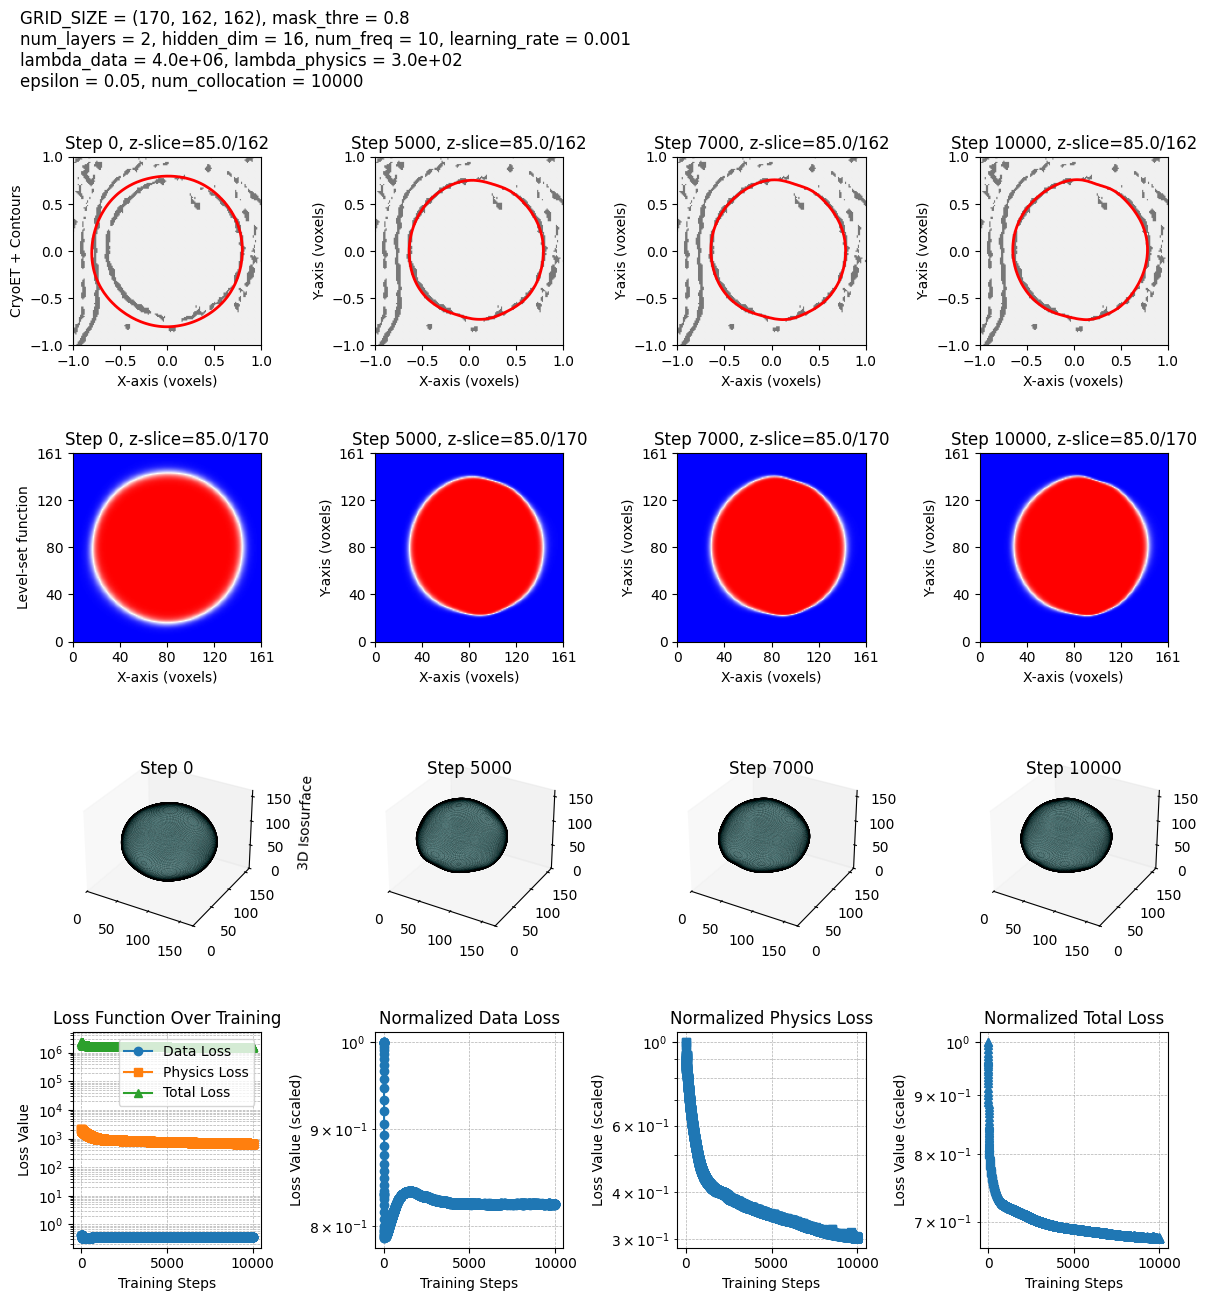

/home/minisemin/matsulab/pinn-exploration-model/outputs/logs/74_S5_normalized_preprocessed/lambda_4000000_300_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint


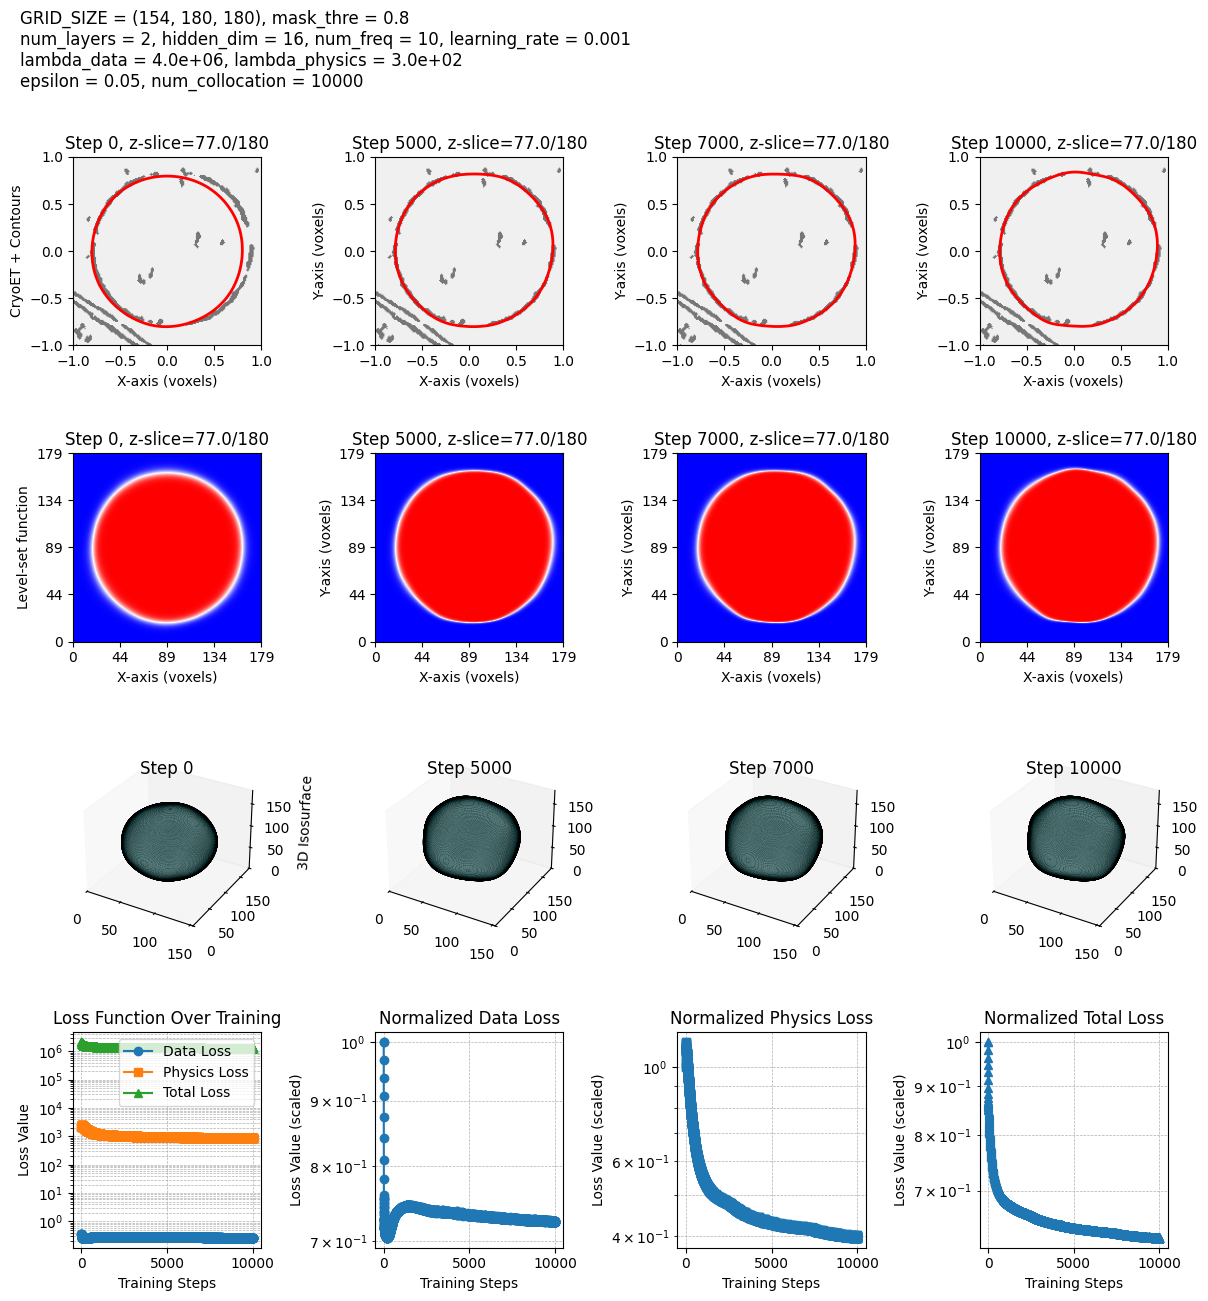

/home/minisemin/matsulab/pinn-exploration-model/outputs/logs/74_SS1_normalized_preprocessed/lambda_4000000_300_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint


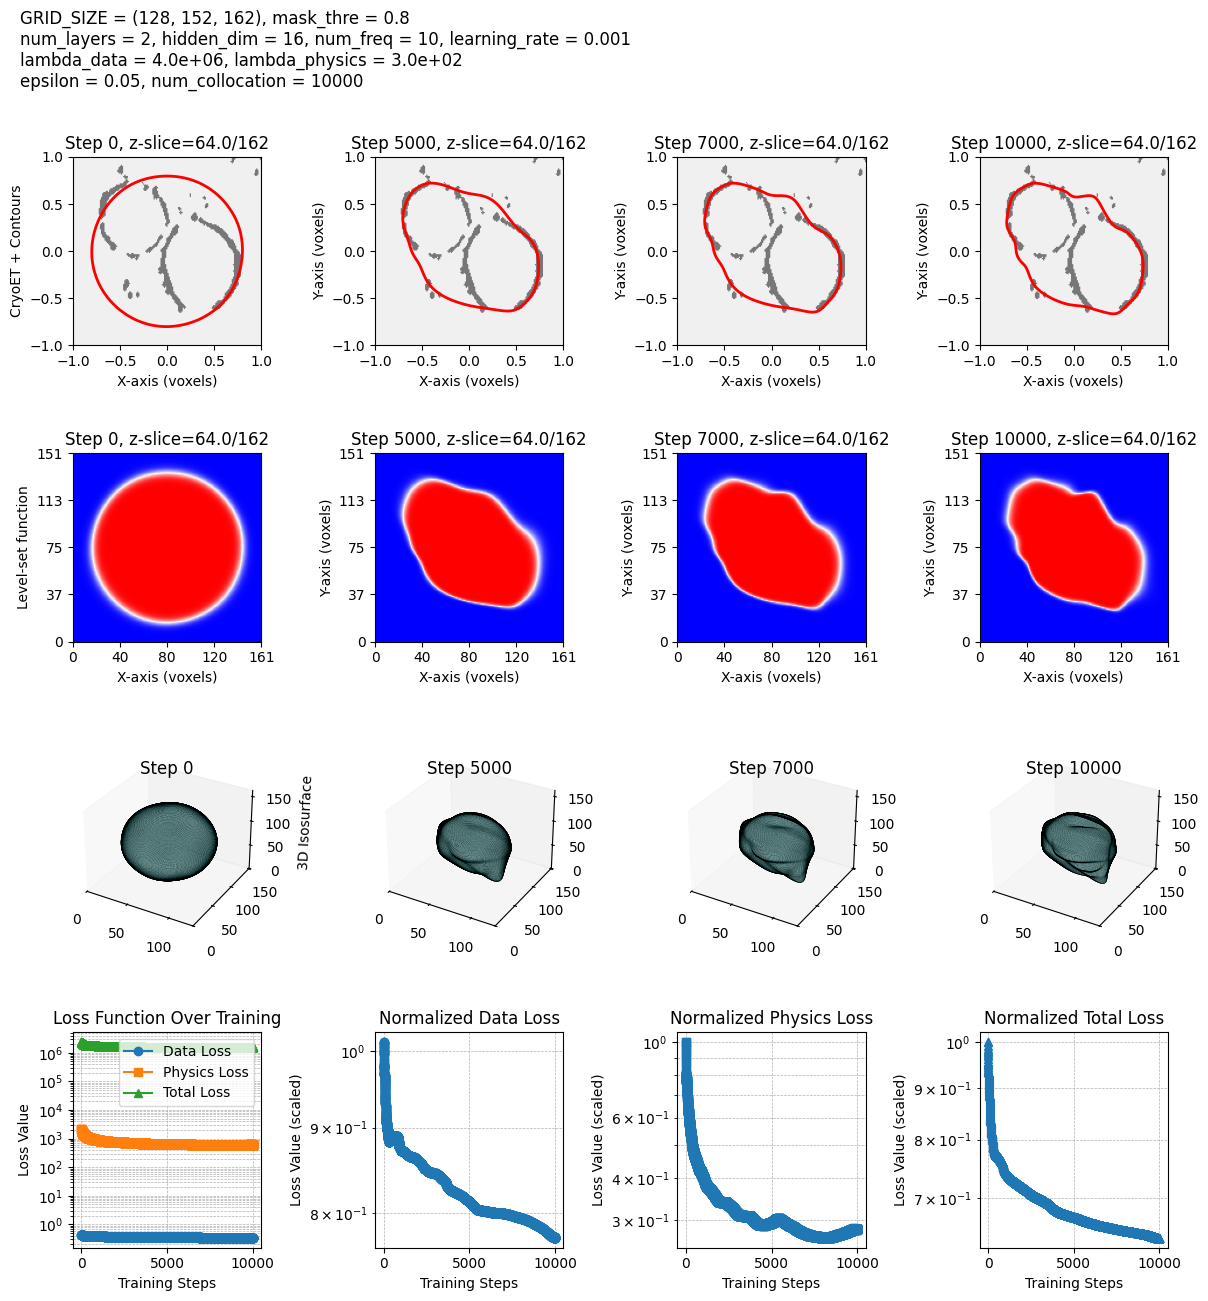

In [13]:
# analysis_basics(s1, lambda_1, lambda_2, mrc_file_path1)
# analysis_basics(s2, lambda_1, lambda_2, mrc_file_path2)
analysis_basics(s3, lambda_1, lambda_2, mrc_file_path3)
# analysis_basics(s4, lambda_1, lambda_2, mrc_file_path4)
analysis_basics(s5, lambda_1, lambda_2, mrc_file_path5)
analysis_basics(ss1, lambda_1, lambda_2, mrc_file_path6)

# Dice Loss

In [20]:
import os
import sys
sys.path.append('../src')
import numpy as np
import jax, jax.numpy as jnp
import mrcfile

from pinn.grid import phi_on_cryo_grid_xyz
from pinn.plot import _to_zyx
from pinn.train import create_train_state
from pinn.model import PINN, EPSILON, LEARNING_RATE, WEIGHT_IN

lambda_1 = 4000000
lambda_2 = 300
shape = "74_SS1_normalized_preprocessed"
mask_shape = "74_SS1"
data_dir = "Jake_Cropped"

mrc_file_path = f"../data/{data_dir}/{shape}.mrc"
mask_file_path = f"../data/{data_dir}/{mask_shape}_mask.mrc"
checkpoint_dir = os.path.abspath(
    f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}/checkpoint"
)

In [5]:
from pinn.checkpoint_io import load_checkpoint_at_step
import napari

with mrcfile.open(mask_file_path, permissive=True) as mrc:
    gt_mask = np.asarray(mrc.data, dtype=np.float32)

gt_mask = np.where(gt_mask > 0.5, 1, 0)

checkpoint_data = load_checkpoint_at_step(5000, checkpoint_dir, lambda_1, lambda_2)
state = checkpoint_data["state"]; params = state["params"]
model = PINN()
phi_fn = lambda x: model.apply(params, x.reshape(-1, 3))
phi_xyz, _, _ = phi_on_cryo_grid_xyz(phi_fn, gt_mask.shape, lo=-1.0, hi=1.0)
phi_zyx = _to_zyx(np.array(phi_xyz))  
lo, hi = (-0.8, 0.8)
pred_mask = (phi_zyx > lo) & (phi_zyx < hi)

In [6]:
viewer = napari.Viewer()
viewer.add_image(
    gt_mask,
    name="GT Mask",
    colormap="gray",
    contrast_limits=(0, 1),
    blending="additive",
    opacity=0.6,
    rendering="attenuated_mip",       # 또는 'attenuated_mip', 'iso' 등 시도해보세요
)

viewer.add_labels(
    pred_mask,
    name="Prediction",
    opacity=0.5,
)

napari.run()

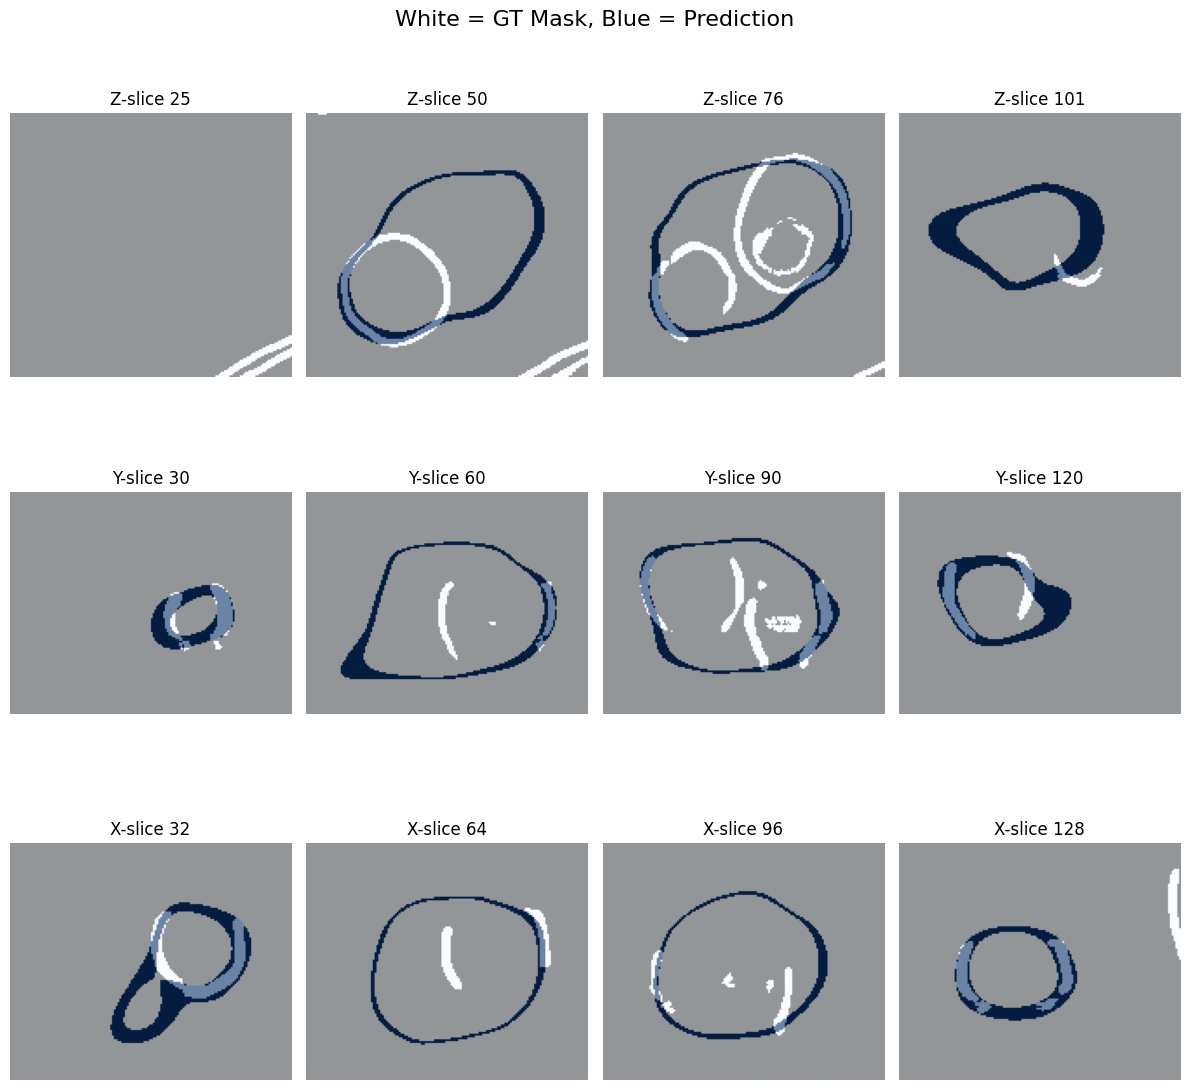

intersection: 27786
intersection/mask: 0.3451334028916381
gt: 80508 / 3151872
pd: 117151 / 3151872
volume_sum: 197659
Dice: 0.281151
0.71884912905561


In [21]:
from pinn.checkpoint_io import load_checkpoint_at_step
from pinn.analysis import dice_loss_pinn_vs_mask

checkpoint_data = load_checkpoint_at_step(5000, checkpoint_dir, lambda_1, lambda_2)
dice_loss_pinn = dice_loss_pinn_vs_mask(mask_file_path, checkpoint_data, band=(-0.7, 0.7), verbose=True)
print(dice_loss_pinn)

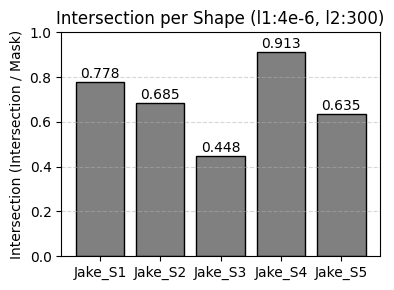

In [22]:
import matplotlib.pyplot as plt

# 너가 직접 넣을 Dice loss 값
dice_losses = {
    "Jake_S1": 0.7777370590929913,
    "Jake_S2": 0.6854350062878701,
    "Jake_S3": 0.44843661171119953,
    "Jake_S4": 0.9131803674631243,
    "Jake_S5": 0.6353956866465813
}

# 데이터 분리
shapes = list(dice_losses.keys())
loss_values = list(dice_losses.values())

# 시각화
plt.figure(figsize=(4, 3))
bars = plt.bar(shapes, loss_values, color="gray", edgecolor="black")

# 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f"{height:.3f}", ha='center', va='bottom', fontsize=10)

plt.ylim(0, 1)
plt.ylabel("Intersection (Intersection / Mask)")
plt.title("Intersection per Shape (l1:4e-6, l2:300)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### ZYX Overlay

In [ ]:
from pinn.checkpoint_io import load_checkpoint_at_step
import napari
import sys
sys.path.append('../src')
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  
import numpy as np
import jax
import jax.numpy as jnp
import mrcfile
import matplotlib.pyplot as plt
from pinn.model import PINN, EPSILON, LEARNING_RATE
from pinn.cryoet_io import open_raw_data
from pinn.plot import (
    visualize_checkpoint_level_set,
    visualize_checkpoint_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.grid import phi_on_cryo_grid_xyz
from pinn.plot import _to_zyx, visualize_zyx_midslice, visualize_zyx_midslice_vs_overlay
from pinn.train import create_train_state

shape = "62_normalized"
result_shape = "62_normalized_bandpass_dilation_erosion"
data_dir = "VLP_Cropped"
data_path = f"../data/{data_dir}/{shape}.mrc"
lambda_1 = 4000000
lambda_2 = 500

with mrcfile.open(data_path, permissive=True) as mrc:
    data = np.asarray(mrc.data, dtype=np.float32)

checkpoint_dir = os.path.abspath(
    f"../outputs/logs/{result_shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{0.5}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}/checkpoint"
)
checkpoint_data = load_checkpoint_at_step(10000, checkpoint_dir, lambda_1, lambda_2)
state = checkpoint_data["state"]; params = state["params"]
model = PINN()
phi_fn = lambda x: model.apply(params, x.reshape(-1, 3))
phi_xyz, _, (x_axis, y_axis, z_axis) = phi_on_cryo_grid_xyz(phi_fn, data.shape, lo=-1.0, hi=1.0)
phi_zyx = _to_zyx(np.array(phi_xyz))  

In [ ]:
visualize_zyx_midslice(pred_mask)

In [ ]:
lo, hi = (-0.03, 0.03)
pred_mask = (phi_zyx > lo) & (phi_zyx < hi)

In [ ]:
visualize_zyx_midslice_vs_overlay(data, pred_mask, title="Normalized data vs Prediction (-0.02 ~ 0.02)")

In [ ]:
from skimage.measure import marching_cubes
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

z, y, x = data.shape

vmin = float(phi_zyx.min())
vmax = float(phi_zyx.max())
sp = (2.0 / float(z), 2.0 /float(y), 2.0 / float(x))

if vmin == vmax:
    print(f"Warning: φ is constant (value={vmin:.6g}); no isosurface to extract.")

if not (vmin <= 0.0 <= vmax):
    # 0 not inside the range; pick midpoint
    level = 0.5 * (vmin + vmax)
    print(f"Warning: φ range = [{vmin:.4g}, {vmax:.4g}] does not include 0; using level={level:.6g} for isosurface.")
else:
    level = 0.0
verts, faces, _, _ = marching_cubes(phi_zyx, level=level, spacing=sp)
verts -= 1.0

mesh = Poly3DCollection(verts[faces], alpha=0.1, edgecolor="k", linewidth=0.2, facecolor="cyan")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 슬라이스 인덱스
slice_z_idx = z // 2
slice_y_idx = y // 2
slice_x_idx = x // 2

# --------- slice Z (y-x plane) ---------
slice_z = phi_zyx[slice_z_idx, :, :]   # shape: (y, x)

# 픽셀 좌표 meshgrid (no scaling)
Xz, Yz = np.meshgrid(np.arange(x), np.arange(y))

axes[0].imshow(norm_data[slice_z_idx, :, :], cmap="gray", alpha=1.0)
axes[0].contour(Xz, Yz, slice_z, levels=[0.0],
               colors='cyan', linewidths=2, alpha=0.4)
axes[0].set_title(f"mid z = {slice_z_idx}")

# --------- slice Y (z-x plane) ---------
slice_y = phi_zyx[:, slice_y_idx, :]   # shape: (z, x)

Xy, Zy = np.meshgrid(np.arange(x), np.arange(z))

axes[1].imshow(norm_data[:, slice_y_idx, :], cmap="gray", alpha=1.0)
axes[1].contour(Xy, Zy, slice_y, levels=[0.0],
                colors='cyan', linewidths=2, alpha=0.4)
axes[1].set_title(f"mid y = {slice_y_idx}")

# --------- slice X (z-y plane) ---------
slice_x = phi_zyx[:, :, slice_x_idx]   # shape: (z, y)

Yx, Zx = np.meshgrid(np.arange(y), np.arange(z))

axes[2].imshow(norm_data[:, :, slice_x_idx], cmap="gray", alpha=1.0)
axes[2].contour(Yx, Zx, slice_x, levels=[0.0],
                colors='cyan', linewidths=2, alpha=0.4)
axes[2].set_title(f"mid x = {slice_x_idx}")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 슬라이스 인덱스
slice_z_idx = z // 2 
slice_y_idx = y // 2 
slice_x_idx = x // 2 

# --------- slice Z (y-x plane) ---------
slice_z = phi_zyx[slice_z_idx, :, :]   # shape: (y, x)

# 픽셀 좌표 meshgrid (no scaling)
Xz, Yz = np.meshgrid(np.arange(x), np.arange(y))

axes[0].imshow(binary_bandpass[slice_z_idx, :, :], cmap="gray", alpha=1.0)
axes[0].contour(Xz, Yz, slice_z, levels=[0.0],
                colors='cyan', linewidths=2, alpha=0.4)
axes[0].set_title(f"mid z = {slice_z_idx}")

# --------- slice Y (z-x plane) ---------
slice_y = phi_zyx[:, slice_y_idx, :]   # shape: (z, x)

Xy, Zy = np.meshgrid(np.arange(x), np.arange(z))

axes[1].imshow(binary_bandpass[:, slice_y_idx, :], cmap="gray", alpha=1.0)
axes[1].contour(Xy, Zy, slice_y, levels=[0.0],
                colors='cyan', linewidths=2, alpha=0.4)
axes[1].set_title(f"mid y = {slice_y_idx}")

# --------- slice X (z-y plane) ---------
slice_x = phi_zyx[:, :, slice_x_idx]   # shape: (z, y)

Yx, Zx = np.meshgrid(np.arange(y), np.arange(z))

axes[2].imshow(binary_bandpass[:, :, slice_x_idx], cmap="gray", alpha=1.0)
axes[2].contour(Yx, Zx, slice_x, levels=[0.0],
                colors='cyan', linewidths=2, alpha=0.4)
axes[2].set_title(f"mid x = {slice_x_idx}")

plt.tight_layout()
plt.show()

#### Physics Analysis

In [ ]:
## make one combined physics analysis image

import os
import numpy as np
import matplotlib.pyplot as plt
import mrcfile
import jax.numpy as jnp
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_level_set,
    visualize_physics_loss,
)
from pinn.train import create_train_state   
from pinn.utils import assemble_loss_history
import jax
from pinn.model import (EPSILON, WEIGHT_IN, LEARNING_RATE)

# lambda_1 = 5000000
# lambda_2 = 1
num_layers = 2
# shape = "multi"

steps_to_visualize = [0, 100, 1000, 10000]

# Load checkpoint data
output_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}")
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}/checkpoint")

# Dummy state (template)
dummy_key = jax.random.PRNGKey(0)
dummy_state, _ = create_train_state(
    dummy_key,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    sdf_pretrain=None,
    learning_rate=LEARNING_RATE,
)

checkpoint_data = {}
for step in steps_to_visualize:
    step_tag = f"{step:06d}"
    state_path = os.path.join(checkpoint_dir, f"state_{step_tag}.msgpack")
    loss_path  = os.path.join(checkpoint_dir, f"loss_{step_tag}.npz")
    if os.path.exists(state_path):
        restored_state = load_state_bytes(state_path, dummy_state)
        loss_blob = load_loss_npz(loss_path)
        checkpoint_data[step] = {"state": restored_state, "loss": loss_blob}

with mrcfile.open(mrc_file_path, permissive=True) as mrc:
        cryoET_data = mrc.data.astype(jnp.float32)

# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(4*4, 4*4))


Z = cryoET_data.shape[0]

# Row 1: Phi
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    checkpoint_data[step] = {
    "state": {"params": restored_state.params},
    "loss": loss_blob, 
    }
    visualize_physics_loss(ax, epsilon=EPSILON, step=step,
                           checkpoint=checkpoint_data[step], component="phi",
                           slice_index=32, axis="z", vmin=-1, vmax=1)
    # visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="z", colorbar = True)
    if i == 0:
        ax.set_ylabel(r"$\phi$")

# Row 2: data loss
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_physics_loss(ax, epsilon=EPSILON, step=step,
                           checkpoint=checkpoint_data[step], component="data",
                           slice_index=int(Z/2), axis="z", vmin=0, vmax=5e-7, cryoET_data=cryoET_data)
    if i == 0:
        ax.set_ylabel(r"Data loss")

# Row 3: physics loss
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1)
    visualize_physics_loss(ax, epsilon=EPSILON, step=step,
                           checkpoint=checkpoint_data[step], component="residual",
                           slice_index=32, axis="z", vmin=0, vmax=150)

    if i == 0:
        ax.set_ylabel(r"$|\Delta \phi - (1/\epsilon^2)(\phi^2 - 1)\phi|$")

# Row 4: tension energy
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 12 + i + 1)
    visualize_physics_loss(ax, epsilon=EPSILON, step=step,
                           checkpoint=checkpoint_data[step], component="tension",
                           slice_index=int(Z/2), axis="z", vmin=0, vmax=400)
    if i == 0:
        ax.set_ylabel(r"$|\nabla \phi|^2 + (1/2\epsilon^2) (\phi^2 -1)^2$")
        # ax.set_ylabel(r"$|\nabla\phi|^2$")


info_text = (
    f"GRID_SIZE = {cryoET_data.shape}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = {LEARNING_RATE}\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = {EPSILON}, num_collocation = {NUM_COLLOCATION}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"analysis2_{shape}_lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}.png"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Make a movie

import matplotlib.pyplot as plt
import os
from pinn.plot import plot_3d_isosurface
from pinn.train import create_train_state
from flax.training import checkpoints
import imageio
import re
from pinn.model import (WEIGHT_IN, EPSILON, LEARNING_RATE)

steps_to_visualize = list(range(0, 10000, 500))
log_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}/")
frame_dir = os.path.join(log_dir, f"frames")

with mrcfile.open(mrc_file_path, permissive=True) as mrc:
        cryoET_data = mrc.data.astype(jnp.float32)

# Dummy template
dummy_key = jax.random.PRNGKey(0)
dummy_state, _ = create_train_state(
    dummy_key,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    sdf_pretrain=None,
    learning_rate=LEARNING_RATE,
)

def save_isosurface_frame(step, checkpoint, save_dir, shape):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint, shape)
    os.makedirs(save_dir, exist_ok=True)
    filename = os.path.join(save_dir, f"frame_{step:06d}.png")
    plt.savefig(filename, dpi=150)
    plt.close(fig)

def make_movie_from_frames(frame_dir, output="movie.mp4", fps=12, start=0, end=30000):
    pattern = re.compile(r"frame_(\d+)\.png")
    frames = []
    for fname in os.listdir(frame_dir):
        m = pattern.match(fname)
        if m:
            idx = int(m.group(1))
            if start <= idx <= end:
                frames.append((idx, os.path.join(frame_dir, fname)))
    frames.sort(key=lambda x: x[0])
    with imageio.get_writer(output, fps=fps) as writer:
        for _, fp in frames:
            writer.append_data(imageio.imread(fp))

# Render frames
for step in steps_to_visualize:
    step_tag = f"{step:06d}"
    state_path = os.path.join(log_dir, f"checkpoint/state_{step_tag}.msgpack")
    if os.path.exists(state_path):
        restored_state = load_state_bytes(state_path, dummy_state)
        print(f"saving step {step}")
        save_isosurface_frame(step, {"state": {"params": restored_state.params}}, cryoET_data.shape, save_dir=frame_dir, grid_size=Z)

# Make the movie
output = os.path.abspath(os.path.join(frame_dir, f"{shape}_lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}.mp4"))
make_movie_from_frames(frame_dir=frame_dir, output=output)
print("Wrote:", output)


### Compare the result with the segmented mask

[step 10000] band=0.075
Dice: 0.0000 | IoU: 0.0000 | Precision: 0.0000 | Recall: 0.0000 | Accuracy: 0.0000
ASSD: 0.0787 | HD95: 0.3683 (in normalized units)


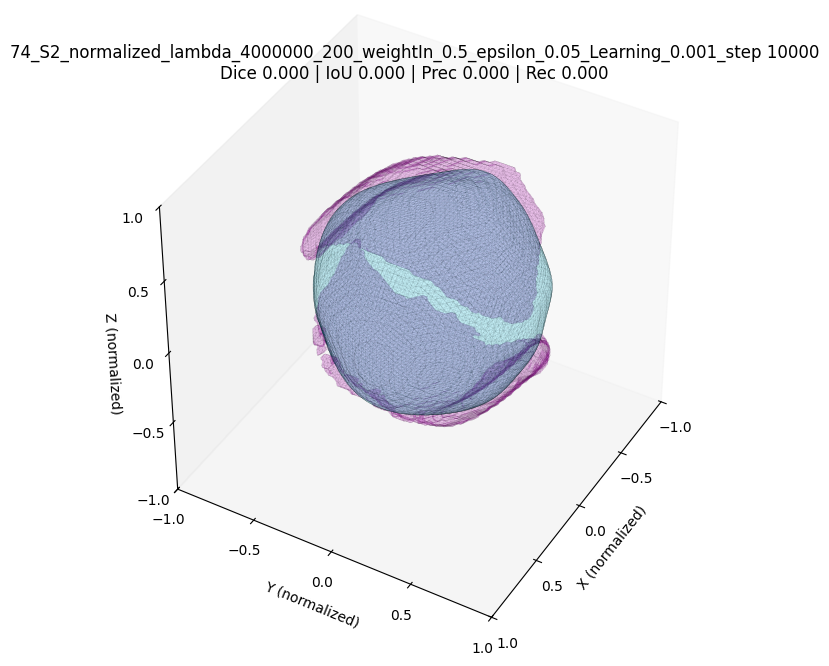

In [ ]:
import os, re
import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage.measure import marching_cubes
from scipy.spatial import cKDTree  # optional, for surface distance metrics

from pinn.train import create_train_state
from pinn.model import (PINN, WEIGHT_IN, EPSILON, LEARNING_RATE)

# Load the final data and the segmented mask
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}/checkpoint")
mask_file_path = f"../data/{data_dir}/{mask_shape}_mask.mrc"

# pick a band around phi=0 to approximate the membrane thickness in voxels
band = 1.5 * EPSILON  # you can tune: 1.0~2.0 * epsilon is typical

state_path, num_steps = find_last_state_path(checkpoint_dir)
assert state_path is not None, "No state_*.msgpack found."

# -------------------------
# Restore model
# -------------------------
dummy_key = jax.random.PRNGKey(0)
dummy_state, _ = create_train_state(
    dummy_key,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    sdf_pretrain=None,
    learning_rate=LEARNING_RATE,
)
restored_state = load_state_bytes(state_path, dummy_state)  # TrainState with .params as you saved
params = restored_state.params

# Build model
model = PINN()  # your class defaults: hidden_dim=16, num_frequencies=10

# -------------------------
# Load ground-truth mask and evaluate φ on the grid
# -------------------------
with mrcfile.open(mask_file_path, permissive=True) as mrc:
        gt_mask = mrc.data.astype(jnp.float32)

phi_fn = lambda x: model.apply(params, x.reshape(-1, 3))
phi_xyz, _, _ = phi_on_cryo_grid_xyz(phi_fn, gt_mask.shape, lo=-1.0, hi=1.0)
phi_zyx = _to_zyx(np.array(phi_xyz))  
# -------------------------
# Predicted membrane mask from a narrow band: |φ| ≤ band
# -------------------------
pred_mask = (np.abs(np.asarray(phi_zyx)) <= band).astype(np.uint8)


# -------------------------
# Metrics (membrane class)
# -------------------------
TP = np.logical_and(pred_mask == 1, mask == 1).sum()
FP = np.logical_and(pred_mask == 1, mask == 0).sum()
FN = np.logical_and(pred_mask == 0, mask == 1).sum()
TN = np.logical_and(pred_mask == 0, mask == 0).sum()
N  = mask.size

dice = (2 * TP) / (2 * TP + FP + FN + 1e-8)
iou  = TP / (TP + FP + FN + 1e-8)
prec = TP / (TP + FP + 1e-8)
rec  = TP / (TP + FN + 1e-8)
acc  = (TP + TN) / N

print(f"[step {num_steps}] band={band:.3f}")
print(f"Dice: {dice:.4f} | IoU: {iou:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | Accuracy: {acc:.4f}")


# -------------------------
# (Optional) surface distance metrics using meshes
# -------------------------
def surface_from_volume(vol, level, spacing):
    """
    Make a writable, C-contiguous float32 NumPy array for skimage.marching_cubes.
    Apply the SAME orientation (transpose) to all volumes if you choose to.
    """
    # Bring to host, ensure dtype/contiguity, and make it writable
    v = np.array(jax.device_get(vol), dtype=np.float32, order="C", copy=True)
    # If elsewhere you used a transpose (e.g., phi = phi.T), apply it here to BOTH
    # v = v.transpose(2, 1, 0)  # <- only if you decide to reorient consistently

    verts, faces, _, _ = marching_cubes(
        v,
        level=level,
        spacing=spacing,
        allow_degenerate=False,   # reduces weird triangles
        method="lewiner",
    )
    return verts, faces


# marching_cubes expects spacing matching the axes of the volume passed (Z, Y, X)
spacing = (2.0 / float(Z_len), 2.0 / float(Y_len), 2.0 / float(X_len))

# Predicted surface at φ=0, GT surface at mask=0.5
pred_verts, pred_faces = surface_from_volume(phi_zyx,   level=0.0, spacing=spacing)
gt_verts,   gt_faces   = surface_from_volume(mask,  level=0.5, spacing=spacing)

# shift to [-1,1]^3 to match your plotting convention
pred_verts -= 1.0
gt_verts   -= 1.0

# Average Symmetric Surface Distance (ASSD) & Hausdorff (optional)
try:
    t_pred = cKDTree(pred_verts); t_gt = cKDTree(gt_verts)
    d_pred_to_gt, _ = t_gt.query(pred_verts, k=1)
    d_gt_to_pred, _ = t_pred.query(gt_verts, k=1)
    assd = 0.5 * (d_pred_to_gt.mean() + d_gt_to_pred.mean())
    hd95 = max(np.percentile(d_pred_to_gt, 95), np.percentile(d_gt_to_pred, 95))
    print(f"ASSD: {assd:.4f} | HD95: {hd95:.4f} (in normalized units)")
except Exception as e:
    print("Surface distance metrics skipped (SciPy missing?):", e)

# -------------------------
# 3D overlay visualization (matplotlib)
# -------------------------
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# GT surface (magenta)
mesh_gt = Poly3DCollection(gt_verts[gt_faces], alpha=0.15, facecolor=(0.8, 0.2, 0.8), edgecolor='k', linewidth=0.1)
ax.add_collection3d(mesh_gt)

# Pred surface (cyan)
mesh_pred = Poly3DCollection(pred_verts[pred_faces], alpha=0.15, facecolor=(0.2, 0.8, 0.9), edgecolor='k', linewidth=0.1)
ax.add_collection3d(mesh_pred)

ax.set_xlabel("X (normalized)")
ax.set_ylabel("Y (normalized)")
ax.set_zlabel("Z (normalized)")

ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
ax.set_box_aspect((1,1,1))
ax.view_init(elev=40, azim=30)

ax.set_title(f"{shape}_lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}_step {num_steps}\n"
             f"Dice {dice:.3f} | IoU {iou:.3f} | Prec {prec:.3f} | Rec {rec:.3f}",
             y=0.95)
ticks = [-1, -0.5, 0, 0.5, 1]
ax.set_xticks(ticks); ax.set_yticks(ticks); ax.set_zticks(ticks)
ax.grid(False)
plt.show()

TypeError: Length of x (70) must match number of columns in z (85)

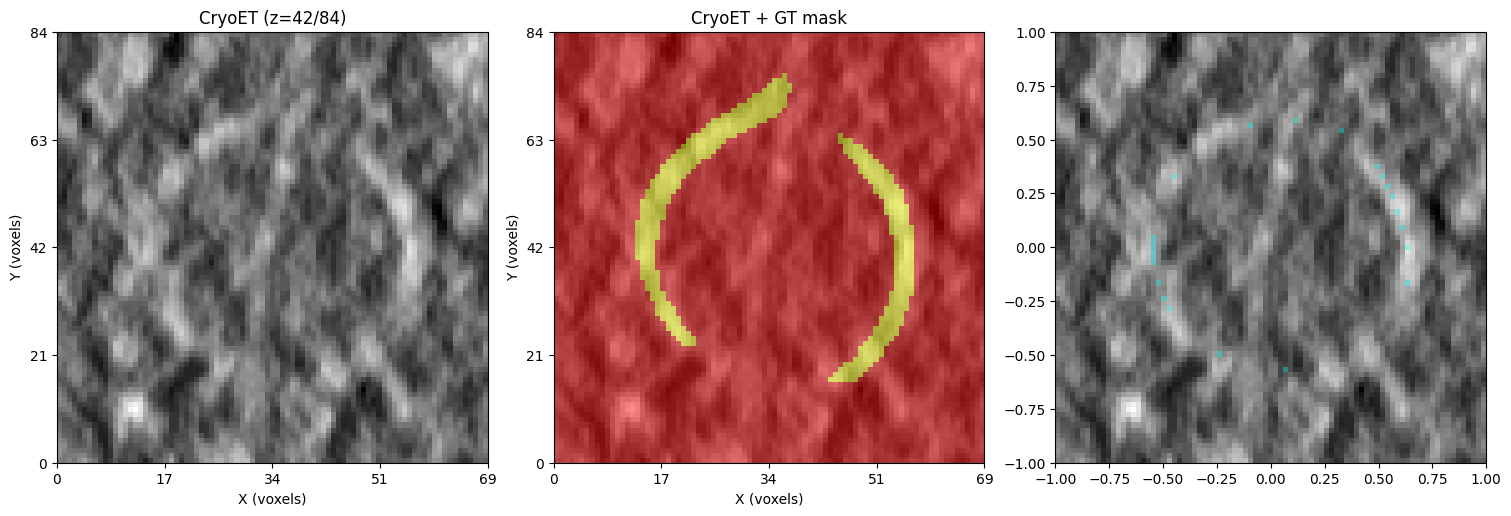

In [35]:
# --- Overlay a specific z-slice: CryoET, GT mask, and predicted phi=0 contour ---

import os, re
import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
from pinn.train import create_train_state
from pinn.model import PINN

# -----------------------------
# Config: choose the slice
# -----------------------------
# Option A: pick normalized z in [-1, 1]
z_value = 0.0                       # e.g., mid-plane; change to -0.5, 0.25, etc.

# Option B: OR pick a voxel index directly (0..GRID_SIZE-1); set to None to use z_value
slice_index_override = None         # e.g., 32

# Optional: also show the predicted "narrow band" |phi| <= band as a semi-transparent overlay
band = 1.5 * EPSILON                # tune 1.0~2.0 * epsilon if you want to see a band

# -----------------------------
# Paths
# -----------------------------
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}/checkpoint")
# mask_file_path = f"../data/{data_dir}/{mask_shape}_mask.mrc"

# -----------------------------
# Helpers
# -----------------------------
def find_last_state_path(ckpt_dir):
    last_path, last_step = None, -1
    pat = re.compile(r"state_(\d{6})\.msgpack$")
    for fn in os.listdir(ckpt_dir):
        m = pat.match(fn)
        if m:
            s = int(m.group(1))
            if s > last_step:
                last_step = s
                last_path = os.path.join(ckpt_dir, fn)
    if last_path is None:
        raise FileNotFoundError(f"No state_*.msgpack in {ckpt_dir}")
    return last_path, last_step

def z_to_index(z, grid_z):
    # map normalized z in [-1,1] -> voxel index [0..grid_z-1]
    idx = int(np.round((float(z) + 1.0) * 0.5 * (grid_z - 1)))
    return int(np.clip(idx, 0, grid_z - 1))

# -----------------------------
# Restore model (latest checkpoint)
# -----------------------------
state_path, num_steps = find_last_state_path(checkpoint_dir)
dummy_key = jax.random.PRNGKey(0)
dummy_state, _ = create_train_state(dummy_key, lambda_1=lambda_1, lambda_2=lambda_2,
                                    sdf_pretrain=None, learning_rate=LEARNING_RATE)
restored_state = load_state_bytes(state_path, dummy_state)   # TrainState
params = restored_state.params
model = PINN()  # your defaults: hidden_dim=16, num_frequencies=10

# -----------------------------
# Load data and evaluate phi
# -----------------------------
with mrcfile.open(mrc_file_path, permissive=True) as mrc:
        cryoET = mrc.data.astype(jnp.float32)         # float [0,1], shape (Z, Y, X)
with mrcfile.open(mask_file_path, permissive=True) as mrc:
        gt_mask = mrc.data.astype(jnp.float32)

phi_fn = lambda x: model.apply(params, x.reshape(-1, 3))
phi_xyz, _, _ = phi_on_cryo_grid_xyz(phi_fn, gt_mask.shape, lo=-1.0, hi=1.0)
phi_zyx = _to_zyx(np.array(phi_xyz))  

# Precompute axes helpers (x corresponds to columns, y to rows)
X, Y, Z = cryoET.shape
x_coords = np.linspace(-1, 1, X)
y_coords = np.linspace(-1, 1, Y)
extent  = [x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()]
voxel_ticks_x = np.linspace(0, X-1, 5).astype(int)
voxel_ticks_y = np.linspace(0, Y-1, 5).astype(int)
norm_ticks_x  = np.linspace(-1, 1, 5)
norm_ticks_y  = np.linspace(-1, 1, 5)

# -----------------------------
# Pick slice (z)
# -----------------------------
if slice_index_override is None:
    k = z_to_index(z_value, Z)
else:
    k = int(np.clip(slice_index_override, 0, Z-1))

# -----------------------------
# Render frames
# -----------------------------
for k in [k]:
    cryo_sl = np.asarray(cryoET[k, :, :])
    mask_sl = np.asarray(gt_mask[k, :, :])
    phi_sl  = np.asarray(phi_zyx[k, :, :])

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

    # (1) CryoET
    axes[0].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)
    axes[0].set_title(f"CryoET (z={k}/{Z-1})")
    axes[0].set_xlabel("X (voxels)"); axes[0].set_ylabel("Y (voxels)")
    axes[0].set_xticks(norm_ticks_x); axes[0].set_xticklabels(voxel_ticks_x)
    axes[0].set_yticks(norm_ticks_y); axes[0].set_yticklabels(voxel_ticks_y)

    # (2) GT overlay
    axes[1].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)
    axes[1].imshow(np.ma.masked_where(mask_sl == 0, mask_sl),
                   cmap="autumn", origin="lower", extent=extent, alpha=0.45)
    axes[1].set_title("CryoET + GT mask")
    axes[1].set_xlabel("X (voxels)"); axes[1].set_ylabel("Y (voxels)")
    axes[1].set_xticks(norm_ticks_x); axes[1].set_xticklabels(voxel_ticks_x)
    axes[1].set_yticks(norm_ticks_y); axes[1].set_yticklabels(voxel_ticks_y)

    # (3) Combined: GT + predicted φ=0 (and the narrow band)
    axes[2].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)

    # Optional predicted band overlay: |phi| <= band
    if band is not None and band > 0:
        pred_band = (np.abs(phi_sl) <= band).astype(np.uint8)
        axes[2].imshow(np.ma.masked_where(pred_band == 0, pred_band),
                       cmap="cool", origin="lower", extent=extent, alpha=0.35)

    # GT contour (magenta) + φ=0 contour (cyan)
    axes[2].contour(x_coords, y_coords, mask_sl, levels=[0.5], colors="magenta", linewidths=1.2)
    axes[2].contour(x_coords, y_coords, phi_sl,  levels=np.linespace(-0,99, 0.99, num=100), colors="cyan",    linewidths=1.6)
    axes[2].set_title(f"CryoET + GT (magenta) + Pred φ=0 (cyan)\nstep {num_steps}")
    axes[2].set_xlabel("X (voxels)"); axes[2].set_ylabel("Y (voxels)")
    axes[2].set_xticks(norm_ticks_x); axes[2].set_xticklabels(voxel_ticks_x)
    axes[2].set_yticks(norm_ticks_y); axes[2].set_yticklabels(voxel_ticks_y)

    plt.show()


In [43]:
# === Movie: sweep through z, showing CryoET + GT + Pred overlays ===
import os, re
import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import imageio.v2 as imageio  # same API as imageio.get_writer
from pinn.train import create_train_state
from pinn.model import PINN

# -----------------------------
# Config
# -----------------------------
band_factor = 1.5        # show predicted |phi| <= band_factor * epsilon as a semi-transparent band
fps         = 12
z_start, z_end, z_step = 0, None, 1   # None => last index; step controls stride (e.g., 2 to skip)
movie_name  = f"overlay_z_sweep_{shape}_lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}.mp4"
output_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{WEIGHT_IN}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}")
checkpoint_dir = os.path.join(output_dir, "checkpoint")
mask_file_path = f"../data/{data_dir}/{mask_shape}_mask.mrc"

frames_dir = os.path.join(checkpoint_dir, "frames_overlay_z")
os.makedirs(frames_dir, exist_ok=True)
movie_path = os.path.join(output_dir, movie_name)

# -----------------------------
# Helpers
# -----------------------------
def find_last_state_path(ckpt_dir):
    last_path, last_step = None, -1
    pat = re.compile(r"state_(\d{6})\.msgpack$")
    for fn in os.listdir(ckpt_dir):
        m = pat.match(fn)
        if m:
            s = int(m.group(1))
            if s > last_step:
                last_step = s
                last_path = os.path.join(ckpt_dir, fn)
    if last_path is None:
        raise FileNotFoundError(f"No state_*.msgpack in {ckpt_dir}")
    return last_path, last_step

# -----------------------------
# Restore model (latest checkpoint)
# -----------------------------
state_path, num_steps = find_last_state_path(checkpoint_dir)
dummy_key = jax.random.PRNGKey(0)
dummy_state, _ = create_train_state(dummy_key, lambda_1=lambda_1, lambda_2=lambda_2,
                                    sdf_pretrain=None, learning_rate=LEARNING_RATE)
restored_state = load_state_bytes(state_path, dummy_state)   # TrainState
params = restored_state.params
model = PINN()

# -----------------------------
# Load data and evaluate phi
# -----------------------------
with mrcfile.open(mrc_file_path, permissive=True) as mrc:
        cryoET = mrc.data.astype(jnp.float32)
with mrcfile.open(mask_file_path, permissive=True) as mrc:
        gt_mask = mrc.data.astype(jnp.float32)          

Z, Y, X = cryoET.shape
# Create linspaces for each axis (note cryoET is (Z, Y, X))
x = jnp.linspace(-1, 1, X)
y = jnp.linspace(-1, 1, Y)
z = jnp.linspace(-1, 1, Z)

# Build coordinate grids shaped (Z, Y, X) to match cryoET ordering.
# We keep the stacking order (x, y, z) for the model but shape the grids so
# when reshaped the phi array has shape (Z, Y, X) and aligns with cryoET.
Zg, Yg, Xg = jnp.meshgrid(z, y, x, indexing="ij")  # shape (Z, Y, X)
pts = jnp.stack([Xg.ravel(), Yg.ravel(), Zg.ravel()], axis=-1)  # (N,3) in (x,y,z)

phi = model.apply(params, pts).reshape((Z, Y, X))  # match cryoET ordering

# Precompute axes helpers (x corresponds to columns, y to rows)
x_coords = np.linspace(-1, 1, X)
y_coords = np.linspace(-1, 1, Y)
extent  = [x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()]
voxel_ticks_x = np.linspace(0, X-1, 5).astype(int)
voxel_ticks_y = np.linspace(0, Y-1, 5).astype(int)
norm_ticks_x  = np.linspace(-1, 1, 5)
norm_ticks_y  = np.linspace(-1, 1, 5)

band = band_factor * EPSILON

# -----------------------------
# Render frames
# -----------------------------
if z_end is None:
    z_end = Z - 1
z_indices = list(range(int(z_start), int(z_end) + 1, int(z_step)))

for k in z_indices:
    cryo_sl = np.asarray(cryoET[k, :, :])
    mask_sl = np.asarray(gt_mask[k, :, :])
    phi_sl  = np.asarray(phi[k, :, :])

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

    # (1) CryoET
    axes[0].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)
    axes[0].set_title(f"CryoET (z={k}/{Z-1})")
    axes[0].set_xlabel("X (voxels)"); axes[0].set_ylabel("Y (voxels)")
    axes[0].set_xticks(norm_ticks_x); axes[0].set_xticklabels(voxel_ticks_x)
    axes[0].set_yticks(norm_ticks_y); axes[0].set_yticklabels(voxel_ticks_y)

    # (2) GT overlay
    axes[1].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)
    axes[1].imshow(np.ma.masked_where(mask_sl == 0, mask_sl),
                   cmap="autumn", origin="lower", extent=extent, alpha=0.45)
    axes[1].set_title("CryoET + GT mask")
    axes[1].set_xlabel("X (voxels)"); axes[1].set_ylabel("Y (voxels)")
    axes[1].set_xticks(norm_ticks_x); axes[1].set_xticklabels(voxel_ticks_x)
    axes[1].set_yticks(norm_ticks_y); axes[1].set_yticklabels(voxel_ticks_y)

    # (3) Combined: GT + predicted φ=0 (and the narrow band)
    axes[2].imshow(cryo_sl, cmap="gray", origin="lower", extent=extent)

    # Optional predicted band overlay: |phi| <= band
    if band is not None and band > 0:
        pred_band = (np.abs(phi_sl) <= band).astype(np.uint8)
        axes[2].imshow(np.ma.masked_where(pred_band == 0, pred_band),
                       cmap="cool", origin="lower", extent=extent, alpha=0.35)

    # GT contour (magenta) + φ=0 contour (cyan)
    axes[2].contour(x_coords, y_coords, phi_sl,  levels=np.linspace(-0.8, 0.8, num=1000), colors="cyan",    linewidths=1.2)
    axes[2].contour(x_coords, y_coords, mask_sl, levels=[0.5], colors="magenta", linewidths=1.2)
    axes[2].set_title(f"CryoET + GT (magenta) + Pred φ=0 (cyan)\nstep {num_steps}")
    axes[2].set_xlabel("X (voxels)"); axes[2].set_ylabel("Y (voxels)")
    axes[2].set_xticks(norm_ticks_x); axes[2].set_xticklabels(voxel_ticks_x)
    axes[2].set_yticks(norm_ticks_y); axes[2].set_yticklabels(voxel_ticks_y)

    frame_path = os.path.join(frames_dir, f"overlay_{k:04d}.png")
    plt.savefig(frame_path, dpi=140)
    plt.close(fig)

# -----------------------------
# Assemble MP4
# -----------------------------
with imageio.get_writer(movie_path, fps=fps) as writer:
    for k in z_indices:
        frame_path = os.path.join(frames_dir, f"overlay_{k:04d}.png")
        writer.append_data(imageio.imread(frame_path))

print("Wrote movie:", movie_path)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (2100, 700) to (2112, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
/home/minisemin/anaconda3/envs/pinn/lib/python3.11/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


Wrote movie: /home/minisemin/matsulab/pinn-exploration-model/outputs/logs/74_S2_normalized/lambda_4000000_200_weightIn_0.5_epsilon_0.05_Learning_0.001/overlay_z_sweep_74_S2_normalized_lambda_4000000_200_weightIn_0.5_epsilon_0.05_Learning_0.001.mp4
